# Exploratory Data Analysis: Neuroblastoma RNA-seq and Microarray Data

This notebook performs the first-pass exploratory analysis for a machine learning project on neuroblastoma clinical endpoint prediction.

**Main goals**

- Load and inspect RNA-seq, microarray, and patient metadata.
- Align expression sample identifiers with patient IDs.
- Explore clinical outcome distributions and class imbalance.
- Visualize relationships between clinical variables and death-from-disease status.
- Run PCA to assess whether expression profiles naturally separate clinical groups.
- Save key figures into `figures/`

## 0. Notebook setup

Import standard scientific Python libraries, define project paths, and create helper functions for saving figures.

In [4]:
# importing the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # plotting and visulisation
import seaborn as sns # nicer (easier) visualisation
%matplotlib inline

print(np.__version__, pd.__version__, sns.__version__) # type: ignore

# for saving
import os,os.path

# for machine learning (preprocessing, dimensionality reduction, feature selection)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold

# for machine learning (supervised learning and evaluation)
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

# for machine learning (ROC curve)
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc

# Project-wide setup
# Creates folders used by the notebook when saving figures/tables.
from pathlib import Path
import warnings

PROJECT_ROOT = Path.cwd()
FIG_DIR = PROJECT_ROOT / ".." / "figures"
RESULTS_DIR = PROJECT_ROOT / ".." / "results"
FIG_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
warnings.filterwarnings("ignore")

def save_current_fig(filename: str, dpi: int = 300):
    """Save the active matplotlib figure to the figures/ directory."""
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path}")

2.2.6 2.3.3 0.13.2


## 1. Data loading

The project uses three files:

- `log2FPKM.tsv`: RNA-seq expression matrix.
- `allProbIntensities.tsv`: microarray probe intensity matrix.
- `patientInfo.tsv`: clinical metadata and endpoint labels.

### Setting up directory and filenames

In [5]:
data_dir = '../data'

fn_fpkm             = '../data/log2FPKM.tsv'
fn_patient_info     = '../data/patientInfo.tsv'
fn_prop_intensities = '../data/allProbIntensities.tsv'

### Load the RNA-seq data

This part already sets the indices in the DataFrame. Please feel free to change as required.

In [6]:
df_fpkm = pd.read_csv('{}/{}'.format(data_dir,fn_fpkm),sep='\t',).rename({'00gene_id':'gene_id'},axis=1)
df_fpkm = df_fpkm.set_index(['gene_id'])
df_fpkm.columns.name = 'ID'

df_fpkm.head()

ID,NB001,NB002,NB003,NB004,NB005,NB006,NB007,NB008,NB009,NB010,...,NB489,NB490,NB491,NB492,NB493,NB494,NB495,NB496,NB497,NB498
gene_id,,,,,,,,,,,,,,,,,,,,,
1/2-SBSRNA4,0.834381,0.743094,0.909414,0.795775,0.905540,0.869154,1.811352,0.599240,0.981855,1.066399,...,0.997977,1.003559,0.842437,1.057873,0.805515,0.491331,0.868249,0.911379,0.660139,1.152988
A1BG,1.910053,0.941996,1.950857,1.989477,1.942946,1.927608,1.617745,2.161291,1.436439,2.159797,...,2.336929,2.836360,1.205317,2.439868,1.649027,1.451425,1.493852,1.641241,1.994978,1.289534
A1BG-AS1,1.453191,0.640614,1.156765,1.525277,1.365043,0.899212,1.304178,1.189205,0.771248,1.114787,...,1.182908,1.367371,0.643751,1.096815,0.925425,0.933275,1.208723,0.904511,1.529221,1.102866
A1CF,0.005102,0.005902,0.005192,0.000000,0.025347,0.005682,0.000000,0.000000,0.021880,0.000000,...,0.024298,0.007295,0.000000,0.006678,0.005746,0.004998,0.004853,0.000000,0.022780,0.018720
A2LD1,0.580151,0.738233,0.927667,0.936497,0.924853,0.739038,1.018705,0.546324,0.666877,0.865850,...,0.673627,1.401265,0.837443,0.939849,0.743496,0.957837,0.812093,0.488748,1.068072,0.782887


### Load the Microarray data

This part already sets the indices in the DataFrame. Please feel free to change as required.

In [7]:
df_prop_intensities = pd.read_csv('{}/{}'.format(data_dir,fn_prop_intensities),sep='\t').set_index(['Reporter.Identifier'])
df_prop_intensities.columns.name = 'ID'

df_prop_intensities.head()

ID,GeneSymbols,NB001,NB002,NB003,NB004,NB005,NB006,NB007,NB008,NB009,...,NB489,NB490,NB491,NB492,NB493,NB494,NB495,NB496,NB497,NB498
Reporter.Identifier,,,,,,,,,,,,,,,,,,,,,
28913,NaN,14.99,14.94,12.48,14.63,11.89,15.09,13.07,12.00,11.70,...,13.62,13.03,14.98,13.36,13.90,13.00,13.79,14.70,14.03,12.31
27262,NaN,9.20,10.41,9.27,8.83,7.97,10.33,9.62,8.72,9.36,...,6.26,5.93,6.97,5.99,7.62,7.76,8.56,7.74,7.57,7.08
3180,NaN,5.06,5.26,6.45,2.89,2.00,4.80,3.05,6.39,6.43,...,0.93,0.58,1.26,1.38,3.49,2.07,2.26,2.29,2.63,2.54
41426,MBL1P,7.45,8.68,6.30,7.30,6.26,7.50,7.43,6.98,8.02,...,5.35,5.57,5.51,6.30,6.60,6.38,7.49,6.77,8.13,7.11
37033,NaN,6.74,6.63,6.75,6.20,6.57,6.01,6.78,4.80,5.15,...,4.58,4.61,3.54,4.55,4.20,7.16,7.07,5.07,6.28,6.34


### Load the patient factors, including the potential endpoints 

This part already sets the indices in the DataFrame. Please feel free to change as required. 
Please note, that the ```FactorValues``` should have a 1-to-1 correspondence to the factors desc ribed in the abstract.

In [8]:
df_patient_info = pd.read_csv('{}/{}'.format(data_dir,fn_patient_info),sep='\t').set_index('ID')
df_patient_info.columns.name = 'FactorValues'

df_patient_info.head()

FactorValues,FactorValue..Sex.,FactorValue..age.at.diagnosis.,FactorValue..death.from.disease.,FactorValue..high.risk.,FactorValue..inss.stage.,FactorValue..progression.
ID,,,,,,
NB498,female,530,NaN,NaN,NaN,NaN
NB497,female,379,0.0,0.0,1,0.0
NB496,male,132,NaN,NaN,NaN,NaN
NB495,male,163,0.0,0.0,1,0.0
NB494,male,56,NaN,NaN,NaN,NaN


####  Divide into training and external testing

As you might have already noticed, we removed some of the factor values for some of the patient **ID**s.
Every row, where this information is missing indicate a real validation entry. We can use this information and create two separate DataFrames, one for training, one for the validation (testing). 

The task is to predict the missing values, either with the RNASeq or the Microarray data, or potentially both?

In [9]:
df_patient_info_train  = df_patient_info[df_patient_info['FactorValue..death.from.disease.'].notna()]
df_patient_info_test   = df_patient_info[df_patient_info['FactorValue..death.from.disease.'].isna()]



In [10]:
df_patient_info_train.head()

FactorValues,FactorValue..Sex.,FactorValue..age.at.diagnosis.,FactorValue..death.from.disease.,FactorValue..high.risk.,FactorValue..inss.stage.,FactorValue..progression.
ID,,,,,,
NB497,female,379,0.0,0.0,1,0.0
NB495,male,163,0.0,0.0,1,0.0
NB493,male,190,0.0,0.0,1,0.0
NB491,male,2326,0.0,1.0,4,1.0
NB489,female,865,0.0,1.0,4,0.0


In [11]:
df_patient_info_test.head()

FactorValues,FactorValue..Sex.,FactorValue..age.at.diagnosis.,FactorValue..death.from.disease.,FactorValue..high.risk.,FactorValue..inss.stage.,FactorValue..progression.
ID,,,,,,
NB498,female,530,NaN,NaN,NaN,NaN
NB496,male,132,NaN,NaN,NaN,NaN
NB494,male,56,NaN,NaN,NaN,NaN
NB492,male,947,NaN,NaN,NaN,NaN
NB490,female,1759,NaN,NaN,NaN,NaN


## 2. Sample alignment and metadata checks

Expression matrices use longer sequencing/library IDs, while patient metadata uses shorter patient IDs. The next cells standardize identifiers and confirm the overlap between expression samples and labelled patients.

In [12]:
# sanity checks on shapes + IDs (are the same samples in the same order across all dataframes?)
print("RNA-Seq df_fpkm shape (genes x samples):", df_fpkm.shape)
print("patient train shape:", df_patient_info_train.shape)
print("patient test shape :", df_patient_info_test.shape)

# Expression samples are the columns of df_fpkm
expr_ids = pd.Index(df_fpkm.columns)

train_ids = pd.Index(df_patient_info_train.index)
test_ids  = pd.Index(df_patient_info_test.index)

print("\n# of expression sample IDs:", len(expr_ids))
print("# of train patient IDs    :", len(train_ids))
print("# of test patient IDs     :", len(test_ids))

print("\nOverlap with expression:")
print("train ∩ expr:", len(train_ids.intersection(expr_ids)))
print("test  ∩ expr:", len(test_ids.intersection(expr_ids)))
    
print("\nAny train IDs missing expression?:", len(train_ids.difference(expr_ids)))
print("Any test IDs missing expression? :", len(test_ids.difference(expr_ids)))


RNA-Seq df_fpkm shape (genes x samples): (23146, 498)
patient train shape: (249, 6)
patient test shape : (249, 6)

# of expression sample IDs: 498
# of train patient IDs    : 249
# of test patient IDs     : 249

Overlap with expression:
train ∩ expr: 84
test  ∩ expr: 84

Any train IDs missing expression?: 165
Any test IDs missing expression? : 165


In [13]:
# inspect columns in patient info (train)
print("Columns in patient info (train):")
display(df_patient_info_train.columns)

# quick peek at first rows
display(df_patient_info_train.head(5))

# missingness summary (top 15 columns with most missing)
missing = df_patient_info_train.isna().sum().sort_values(ascending=False)
display(missing.head(15))


Columns in patient info (train):


Index(['FactorValue..Sex.', 'FactorValue..age.at.diagnosis.',
       'FactorValue..death.from.disease.', 'FactorValue..high.risk.',
       'FactorValue..inss.stage.', 'FactorValue..progression.'],
      dtype='object', name='FactorValues')

FactorValues,FactorValue..Sex.,FactorValue..age.at.diagnosis.,FactorValue..death.from.disease.,FactorValue..high.risk.,FactorValue..inss.stage.,FactorValue..progression.
ID,,,,,,
NB497,female,379,0.0,0.0,1,0.0
NB495,male,163,0.0,0.0,1,0.0
NB493,male,190,0.0,0.0,1,0.0
NB491,male,2326,0.0,1.0,4,1.0
NB489,female,865,0.0,1.0,4,0.0


FactorValues
FactorValue..Sex.                   0
FactorValue..age.at.diagnosis.      0
FactorValue..death.from.disease.    0
FactorValue..high.risk.             0
FactorValue..inss.stage.            0
FactorValue..progression.           0
dtype: int64

In [14]:
# Extract patient IDs from expression column names
expr_patient_ids = [col.split("_")[0] for col in df_fpkm.columns]

# Check mapping
mapping_df = pd.DataFrame({
    "original_id": df_fpkm.columns,
    "patient_id": expr_patient_ids
})

mapping_df.head()

# Rename columns to patient IDs
df_fpkm_renamed = df_fpkm.copy()
df_fpkm_renamed.columns = expr_patient_ids


print("Expression matrix after aggregation:", df_fpkm_renamed.shape)

Expression matrix after aggregation: (23146, 498)


In [21]:
# restrict to patients with RNA-Seq data

# Expression sample IDs
expr_ids = pd.Index(df_fpkm_renamed.columns)

# Restrict train and test patient info
df_train = df_patient_info_train.loc[
    df_patient_info_train.index.intersection(expr_ids)
].copy()

df_test = df_patient_info_test.loc[
    df_patient_info_test.index.intersection(expr_ids)
].copy()

print("Filtered train shape:", df_train.shape)
print("Filtered test shape :", df_test.shape)

# Sanity check
print("\nOverlap after filtering:")
print("train ∩ expr:", len(df_train.index.intersection(expr_ids)))
print("test  ∩ expr:", len(df_test.index.intersection(expr_ids)))

y_train = df_train["FactorValue..death.from.disease."]

Filtered train shape: (249, 6)
Filtered test shape : (249, 6)

Overlap after filtering:
train ∩ expr: 249
test  ∩ expr: 249


## 3. Clinical exploratory analysis

These plots examine whether clinical variables such as age, sex, and INSS stage are associated with death-from-disease status. They also help communicate class imbalance and clinical context before modelling.

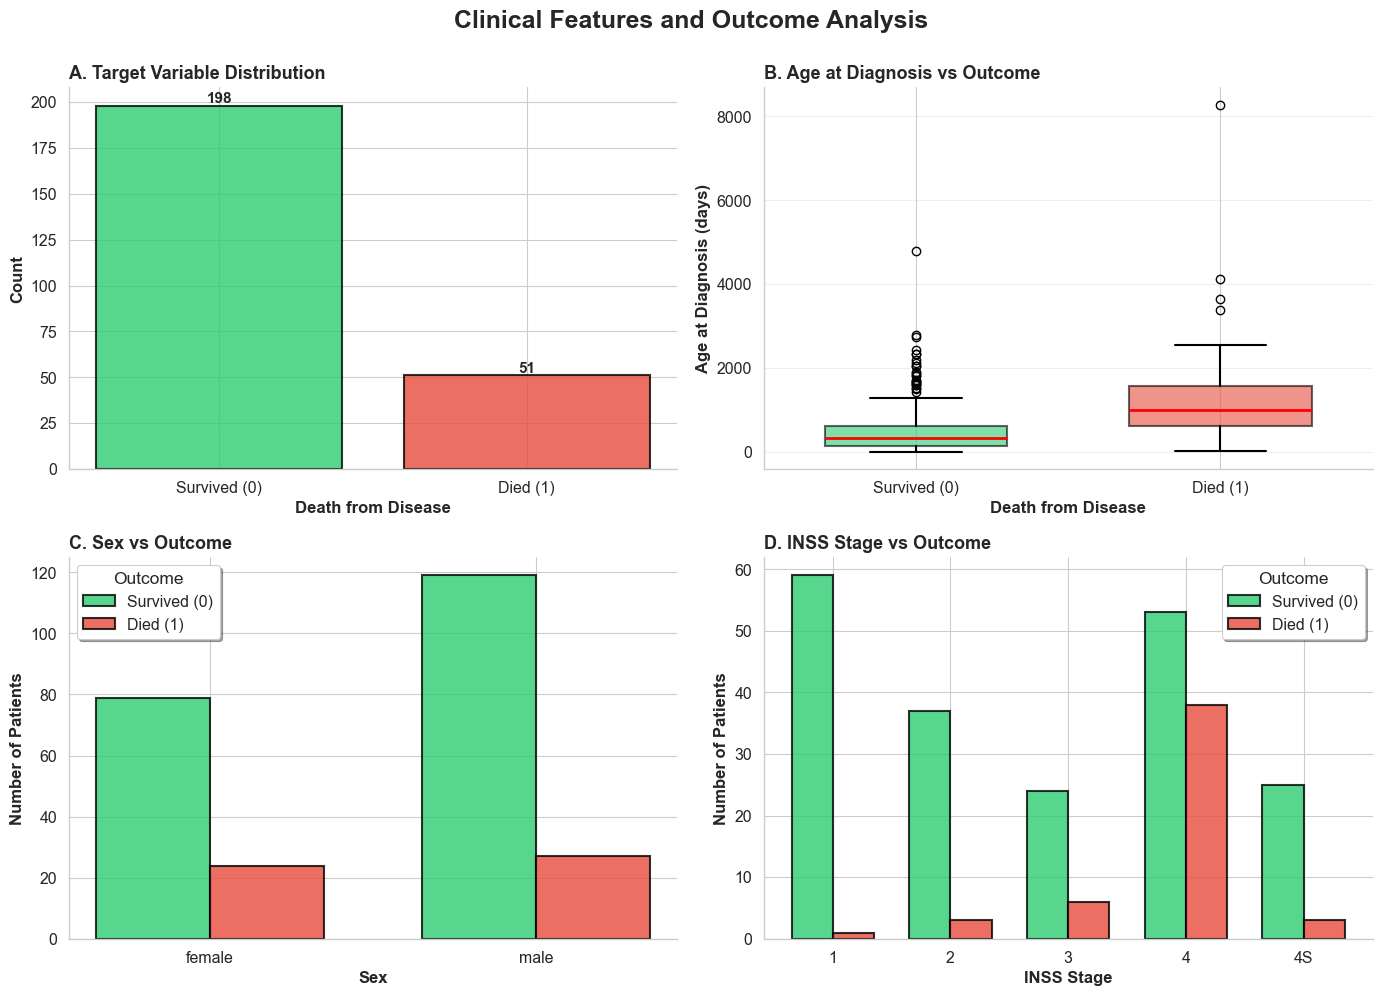


Figure saved as 'clinical_features_analysis.png' at 300 DPI


In [30]:
"""
2x2 grid of clinical features and outcome analysis
"""

# Assuming df_train and y_train are already defined in your environment
# If running standalone, you'll need to load your data first

# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Clinical Features and Outcome Analysis', fontsize=18, fontweight='bold', y=0.995)

# Set publication style
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.3)

# Define color palette
palette = ['#2ecc71', '#e74c3c']  # Green for survived, red for died


# Plot 1: Target distribution (top-left)
ax1 = axes[0, 0]
value_counts = y_train.value_counts().sort_index()
bars = ax1.bar(value_counts.index, value_counts.values, color=palette, 
               edgecolor='black', linewidth=1.5, alpha=0.8)
ax1.set_xlabel('Death from Disease', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('A. Target Variable Distribution', fontsize=13, fontweight='bold', loc='left')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Survived (0)', 'Died (1)'])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')


# Plot 2: Age at diagnosis vs outcome (top-right)
ax2 = axes[0, 1]
bp = ax2.boxplot([df_train[y_train == 0]["FactorValue..age.at.diagnosis."],
                   df_train[y_train == 1]["FactorValue..age.at.diagnosis."]],
                  positions=[0, 1],
                  widths=0.6,
                  patch_artist=True,
                  labels=['Survived (0)', 'Died (1)'],
                  boxprops=dict(facecolor='lightblue', edgecolor='black', linewidth=1.5),
                  medianprops=dict(color='red', linewidth=2),
                  whiskerprops=dict(color='black', linewidth=1.5),
                  capprops=dict(color='black', linewidth=1.5))
# Color boxes
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.set_xlabel('Death from Disease', fontsize=12, fontweight='bold')
ax2.set_ylabel('Age at Diagnosis (days)', fontsize=12, fontweight='bold')
ax2.set_title('B. Age at Diagnosis vs Outcome', fontsize=13, fontweight='bold', loc='left')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Sex vs outcome (bottom-left)
ax3 = axes[1, 0]
target_col = "FactorValue..death.from.disease."
sex_data = df_train.groupby(['FactorValue..Sex.', target_col]).size().unstack(fill_value=0)
x_pos = np.arange(len(sex_data.index))
width = 0.35
bars1 = ax3.bar(x_pos - width/2, sex_data[0], width, label='Survived (0)', 
                color=palette[0], edgecolor='black', linewidth=1.5, alpha=0.8)
bars2 = ax3.bar(x_pos + width/2, sex_data[1], width, label='Died (1)', 
                color=palette[1], edgecolor='black', linewidth=1.5, alpha=0.8)
ax3.set_xlabel('Sex', fontsize=12, fontweight='bold')
ax3.set_ylabel('Number of Patients', fontsize=12, fontweight='bold')
ax3.set_title('C. Sex vs Outcome', fontsize=13, fontweight='bold', loc='left')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(sex_data.index)
ax3.legend(title='Outcome', frameon=True, fancybox=True, shadow=True)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Plot 4: INSS stage vs outcome (bottom-right)

ax4 = axes[1, 1]
stage_data = df_train.groupby(['FactorValue..inss.stage.', target_col]).size().unstack(fill_value=0)
x_pos = np.arange(len(stage_data.index))
width = 0.35
bars1 = ax4.bar(x_pos - width/2, stage_data[0], width, label='Survived (0)', 
                color=palette[0], edgecolor='black', linewidth=1.5, alpha=0.8)
bars2 = ax4.bar(x_pos + width/2, stage_data[1], width, label='Died (1)', 
                color=palette[1], edgecolor='black', linewidth=1.5, alpha=0.8)
ax4.set_xlabel('INSS Stage', fontsize=12, fontweight='bold')
ax4.set_ylabel('Number of Patients', fontsize=12, fontweight='bold')
ax4.set_title('D. INSS Stage vs Outcome', fontsize=13, fontweight='bold', loc='left')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(stage_data.index)
ax4.legend(title='Outcome', frameon=True, fancybox=True, shadow=True)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/01_clinical_features_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'clinical_features_analysis.png' at 300 DPI")

## 4. RNA-seq dimensionality reduction using PCA

PCA is used as an unsupervised check of global expression structure. The goal is to see whether major expression axes separate patients by mortality outcome or clinical stage before fitting supervised models.

In [31]:
# prepare RNA-Seq matrix for PCA

# Extract expression for training patients
X_expr_train = df_fpkm_renamed[df_train.index].T  # samples x genes

print("Expression matrix shape (train):", X_expr_train.shape)

# remove zero-variance genes
vt = VarianceThreshold(threshold=0.0)
X_expr_vt = vt.fit_transform(X_expr_train)

print("Original shape:", X_expr_train.shape)
print("After zero-variance filter:", X_expr_vt.shape)

# select top variable genes
# Compute variance per gene (after zero-variance filtering)
gene_variances = X_expr_vt.var(axis=0)

# Indices of top N genes
TOP_N = 2000
top_idx = np.argsort(gene_variances)[-TOP_N:]

X_expr_top = X_expr_vt[:, top_idx]

print("Shape after top-variance selection:", X_expr_top.shape)

Expression matrix shape (train): (249, 23146)
Original shape: (249, 23146)
After zero-variance filter: (249, 21508)
Shape after top-variance selection: (249, 2000)


In [32]:
# PCA

# Scale features
scaler = StandardScaler()
X_expr_top_scaled = scaler.fit_transform(X_expr_top)

print("Scaled matrix shape:", X_expr_top_scaled.shape)

Scaled matrix shape: (249, 2000)


In [33]:
# PCA with stable solver
pca = PCA(
    n_components=2,
    svd_solver="full",
    random_state=42
)

X_pca = pca.fit_transform(X_expr_top_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.21446799 0.1049168 ]
Total variance explained: 0.3193847938221711


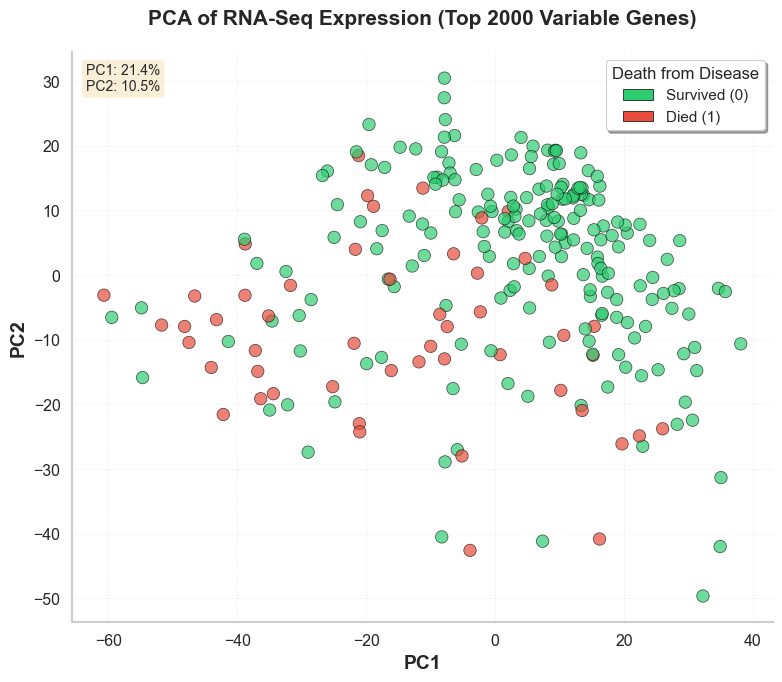


Figure saved as 'pca_expression_analysis.png' at 300 DPI


In [41]:
"""
PCA plot of RNA-Seq expression data labelled by outcome (survived vs died)
"""
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Set publication style
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.3)

# Define color palette (matching the previous plots)
palette = {0: '#2ecc71', 1: '#e74c3c'}  # Green for survived, red for died

# Create figure
fig, ax = plt.subplots(figsize=(8, 7))

# Create scatter plot
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=[palette[val] for val in y_train],
    alpha=0.7,
    s=80,
    edgecolors='black',
    linewidth=0.5
)

# Set labels and title
ax.set_xlabel('PC1', fontsize=14, fontweight='bold')
ax.set_ylabel('PC2', fontsize=14, fontweight='bold')
ax.set_title('PCA of RNA-Seq Expression (Top 2000 Variable Genes)', 
             fontsize=15, fontweight='bold', pad=20)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=palette[0], edgecolor='black', label='Survived (0)', linewidth=0.5),
    Patch(facecolor=palette[1], edgecolor='black', label='Died (1)', linewidth=0.5)
]
ax.legend(
    handles=legend_elements,
    title='Death from Disease',
    title_fontsize=12,
    fontsize=11,
    frameon=True,
    fancybox=True,
    shadow=True,
    loc='best'
)

# Add grid with lower alpha
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Calculate and display explained variance (if available)
# Uncomment if you have access to pca object:
explained_var = pca.explained_variance_ratio_
ax.text(0.02, 0.98, f'PC1: {explained_var[0]:.1%}\nPC2: {explained_var[1]:.1%}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../figures/02_pca_expression_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'pca_expression_analysis.png' at 300 DPI")

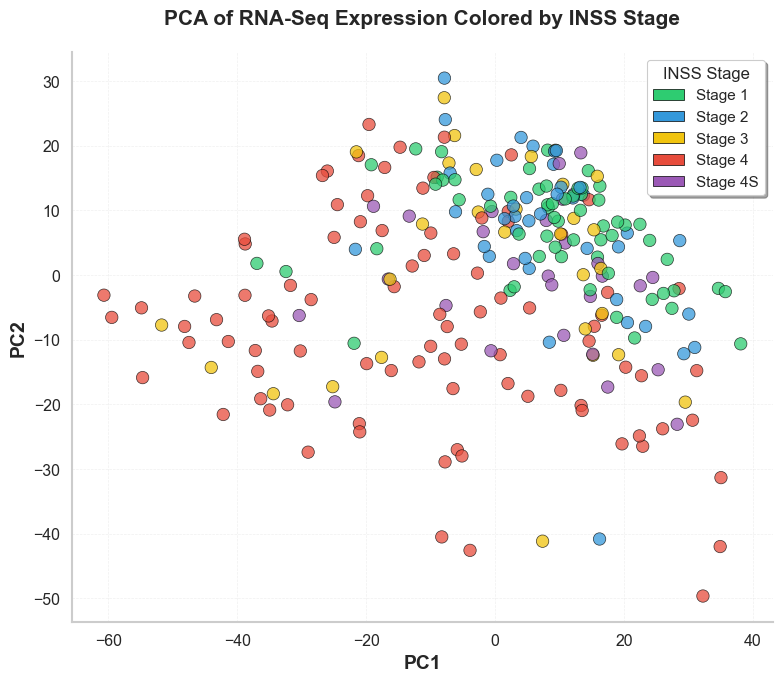


Figure saved as 'pca_expression_inss_stage.png' at 300 DPI


In [ ]:
"""
PCA plot of RNA-Seq expression data colored by INSS stage
"""

# Extract INSS stage labels
y_stage = df_patient_info_train["FactorValue..inss.stage."].astype(str).values

# Set publication style
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.3)

# Define color palette for INSS stages
stage_order = ["1", "2", "3", "4", "4S"]

palette = {
    "1": "#2ecc71",   # green
    "2": "#3498db",   # blue
    "3": "#f1c40f",   # yellow
    "4": "#e74c3c",   # red
    "4S": "#9b59b6"   # purple
}

# Create figure
fig, ax = plt.subplots(figsize=(8, 7))

# Create scatter plot
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=[palette[val] for val in y_stage],
    alpha=0.75,
    s=80,
    edgecolors="black",
    linewidth=0.5
)

# Set labels and title
ax.set_xlabel("PC1", fontsize=14, fontweight="bold")
ax.set_ylabel("PC2", fontsize=14, fontweight="bold")
ax.set_title(
    "PCA of RNA-Seq Expression Colored by INSS Stage",
    fontsize=15,
    fontweight="bold",
    pad=20
)

# Remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Create custom legend
legend_elements = [
    Patch(
        facecolor=palette[stage],
        edgecolor="black",
        label=f"Stage {stage}",
        linewidth=0.5
    )
    for stage in stage_order
    if stage in np.unique(y_stage)
]

ax.legend(
    handles=legend_elements,
    title="INSS Stage",
    title_fontsize=12,
    fontsize=11,
    frameon=True,
    fancybox=True,
    shadow=True,
    loc="best"
)

# Add grid
ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.savefig("../figures/03_pca_expression_inss_stage.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nFigure saved as 'pca_expression_inss_stage.png' at 300 DPI")

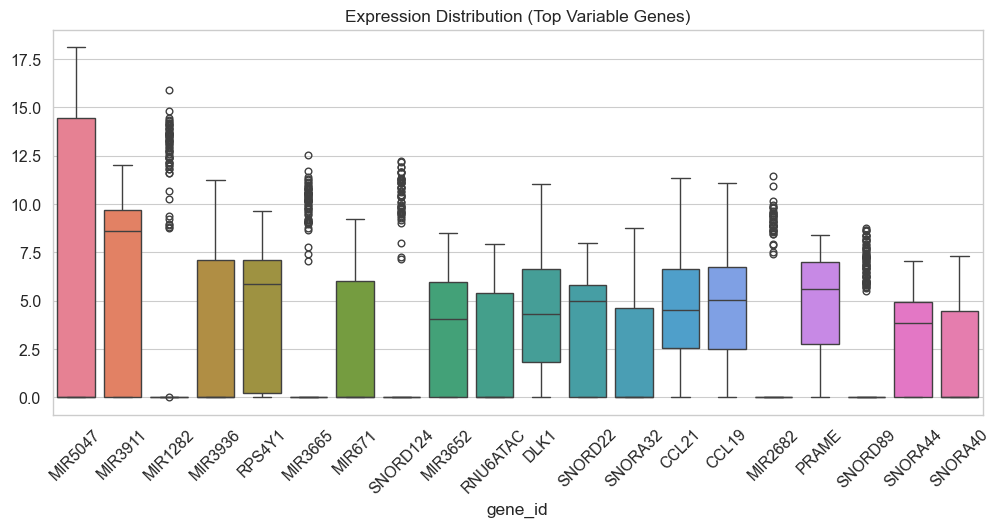

Saved figure: /Users/aman/Downloads/neuroblastoma_ml_portfolio_started/notebooks/../figures/../figures/04_eda_21_import_numpy_as_np.png


<Figure size 640x480 with 0 Axes>

In [42]:
# top 20 variable genes
top_genes = df_fpkm.var(axis=1).sort_values(ascending=False).head(20).index

data_subset = df_fpkm.loc[top_genes].T  # samples x genes

plt.figure(figsize=(12,5))
sns.boxplot(data=data_subset)

plt.title("Expression Distribution (Top Variable Genes)")
plt.xticks(rotation=45)

plt.show()

save_current_fig("../figures/04_eda_21_import_numpy_as_np.png")